# **Brake Pad Design Optimization: Gaussian Process Surrogate Modeling**

This study develops a high-fidelity surrogate model to predict **Maximum Equivalent Stress** as a function of four critical design parameters: **Cocopeat Percentage**, **Inner Diameter**, **Actuation Force**, and **Sweep Angle**. By employing Gaussian Process Regression (GPR), we capture non-linear interactions and quantify prediction uncertainty across the design space.

In [1]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as skl


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

# The `!head` command revealed that the file uses commas as a delimiter
# and contains comment lines starting with '#'.
# We will use `comment='#'` to skip these lines and allow `pd.read_csv`
# to use its default comma separator.
#!head '/content/drive/MyDrive/Colab Notebooks/BrakePadOptm/FivePercentCocopeat.csv'

data1 = pd.read_csv('FivePercentCocopeat.csv', comment='#')
# Rename the 'Name' column to 'percentage' and set its value to '5'
data1 = data1.drop(columns=['P10', 'P11','P14','P15'])
data1 = data1.rename(columns={'Name': 'percentage','P1': 'InnerDiameter','P7':'ActuationForce','P9':'SweepAngle',
                              'P5':'MaxEquivStress','P6':'MaxEquivPlastStrain','P16':'BrakingTorque'})
data1['percentage'] = 5.0
data1['SweepAngle'] = 180.0-2.0*data1['SweepAngle']
print(data1.head())

data2 = pd.read_csv('TenPercentCocopeat.csv', comment='#')
# Rename the 'Name' column to 'percentage' and set its value to '10'
data2 = data2.drop(columns=['P10', 'P11','P14','P15'])
data2 = data2.rename(columns={'Name': 'percentage','P1': 'InnerDiameter','P7':'ActuationForce','P9':'SweepAngle',
                              'P5':'MaxEquivStress','P6':'MaxEquivPlastStrain','P16':'BrakingTorque'})
data2['percentage'] = 10.0
data2['SweepAngle'] = 180.0-2.0*data2['SweepAngle']
print(data2.head())

data3 = pd.read_csv('FifteenPercentCocopeat.csv', comment='#')
# Rename the 'Name' column to 'percentage' and set its value to '15'
data3 = data3.drop(columns=['P10', 'P11','P14','P15'])
data3 = data3.rename(columns={'Name': 'percentage','P1': 'InnerDiameter','P7':'ActuationForce','P9':'SweepAngle',
                              'P5':'MaxEquivStress','P6':'MaxEquivPlastStrain','P16':'BrakingTorque'})
data3['percentage'] = 15.0
data3['SweepAngle'] = 180.0-2.0*data3['SweepAngle']
print(data3.head())



   percentage  InnerDiameter  ActuationForce  SweepAngle  MaxEquivStress  \
0         5.0          133.5    -12333.33333   78.066667        5.428632   
1         5.0          136.5    -15000.00000   77.133333        4.371203   
2         5.0          125.5    -14333.33333   83.666667        4.415671   
3         5.0          135.5    -19666.66667   73.400000        5.307853   
4         5.0          126.5    -18333.33333   82.733333        4.314753   

   MaxEquivPlastStrain  BrakingTorque  
0             0.005450     745.556316  
1             0.000923     845.812716  
2             0.000058     997.186897  
3             0.003187    1122.766639  
4             0.000853    1247.829834  
   percentage  InnerDiameter  ActuationForce  SweepAngle  MaxEquivStress  \
0        10.0          128.5   -15000.000000   75.266667        5.188132   
1        10.0          134.5   -14333.333333   85.533333        5.282357   
2        10.0          132.5   -11000.000000   74.333333        4.391137   

In [3]:
data = pd.concat([data1, data2, data3], ignore_index=True)
display(data)

,percentage,InnerDiameter,ActuationForce,SweepAngle,MaxEquivStress,MaxEquivPlastStrain,BrakingTorque
0,5.0,133.5,-12333.333330,78.066667,5.428632,0.005450,745.556316
1,5.0,136.5,-15000.000000,77.133333,4.371203,0.000923,845.812716
2,5.0,125.5,-14333.333330,83.666667,4.415671,0.000058,997.186897
3,5.0,135.5,-19666.666670,73.400000,5.307853,0.003187,1122.766639
4,5.0,126.5,-18333.333330,82.733333,4.314753,0.000853,1247.829834
5,5.0,139.5,-19000.000000,84.600000,5.411950,0.003135,1016.583447
6,5.0,134.5,-11000.000000,74.333333,4.662846,0.000012,646.007426
7,5.0,138.5,-13000.000000,75.266667,4.844537,0.000523,692.643252
8,5.0,129.5,-17666.666670,79.000000,4.452362,0.001118,1136.602266
9,5.0,128.5,-13666.666670,72.466667,4.755182,0.000305,871.502833


### 1. Data Preparation and Baseline GPR
We begin by standardizing our features to ensure that the GPR length-scales are optimized on a consistent scale. Our baseline model uses an **anisotropic Matern** kernel with one length scale per feature and a **WhiteKernel** to model observation noise for predicting Maximum Equivalent Stress.

In [4]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Define predictors and single response (MaxEquivStress)
X = data[['percentage', 'InnerDiameter', 'ActuationForce', 'SweepAngle']]
y = data['MaxEquivStress']

# Use a larger, composition-stratified holdout so every material group is represented.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=data['percentage'],
)

# Scale features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

def stress_r2(model, features, target):
    return r2_score(target, np.expm1(model.predict(features)))

# Fit in log space to reduce the influence of the high-stress tail.
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Use one length scale per feature and model observation noise explicitly.
kernel = C(1.0, (1e-5, 1e5)) * Matern(
    length_scale=np.ones(X_train_scaled.shape[1]),
    length_scale_bounds=(1e-2, 1e3),
    nu=2.5,
) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-8, 1e2))

# Initialize single-output GPR
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15, normalize_y=True, random_state=42)
gpr.fit(X_train_scaled, y_train_log)

print("Single-output GPR Model (MaxEquivStress) fitted successfully.")
print(f"Training Score (R^2): {stress_r2(gpr, X_train_scaled, y_train):.4f}")
print(f"Testing Score (R^2): {stress_r2(gpr, X_test_scaled, y_test):.4f}")

Single-output GPR Model (MaxEquivStress) fitted successfully.
Training Score (R^2): 1.0000
Testing Score (R^2): 0.3898


### 2. Comparative Kernel Analysis
To ensure the model captures the underlying physics effectively, we evaluate anisotropic kernel architectures with an explicit **WhiteKernel** noise component:
*   **Anisotropic RBF**: A smooth response with feature-specific length scales.
*   **Anisotropic Matern (nu=1.5, 2.5)**: Flexible spatial smoothness with feature-specific length scales.

In [5]:
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, RBF, ConstantKernel as C
from sklearn.gaussian_process import GaussianProcessRegressor

# Compare anisotropic kernels with an explicit white-noise component.
feature_count = X_train_scaled.shape[1]
anisotropic_length_scale = np.ones(feature_count)
noise_kernel = WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-8, 1e2))
candidate_kernels = [
    C(1.0, (1e-6, 1e7)) * RBF(length_scale=anisotropic_length_scale, length_scale_bounds=(1e-5, 1e5)) + noise_kernel,
    C(1.0, (1e-6, 1e7)) * Matern(length_scale=anisotropic_length_scale, length_scale_bounds=(1e-5, 1e5), nu=1.5) + noise_kernel,
    C(1.0, (1e-6, 1e7)) * Matern(length_scale=anisotropic_length_scale, length_scale_bounds=(1e-5, 1e5), nu=2.5) + noise_kernel,
]

results = []

for candidate_kernel in candidate_kernels:
    gpr_temp = GaussianProcessRegressor(kernel=candidate_kernel, n_restarts_optimizer=10, alpha=0.0, normalize_y=True, random_state=42)
    gpr_temp.optimizer_kwargs = {'maxiter': 10000}
    gpr_temp.fit(X_train_scaled, y_train)

    train_score = gpr_temp.score(X_train_scaled, y_train)
    test_score = gpr_temp.score(X_test_scaled, y_test)

    results.append({
        'Kernel Type': candidate_kernel.__class__.__name__ if not hasattr(candidate_kernel, 'k1') else 'Composite',
        'Final Kernel': str(gpr_temp.kernel_),
        'Train R2': train_score,
        'Test R2': test_score
    })

kernel_comparison = pd.DataFrame(results)
print("Anisotropic Kernel Comparison Table:")
display(kernel_comparison.sort_values(by='Test R2', ascending=False))

Anisotropic Kernel Comparison Table:


,Kernel Type,Final Kernel,Train R2,Test R2
0,Composite,"1.01**2 * RBF(length_scale=[0.0835, 2.44, 0.98...",1.0,0.448758
2,Composite,"1.02**2 * Matern(length_scale=[0.0293, 2.33, 1...",1.0,0.248931
1,Composite,"1.02**2 * Matern(length_scale=[0.0231, 2.5, 1....",1.0,0.205793



### 3. Hyperparameter Tuning via Grid Search
We refine our model by performing a **Grid Search with Cross-Validation**. This process optimizes the noise level ($\\alpha$) and kernel parameters, selecting the configuration that maximizes generalization performance ($R^2$) on unseen design configurations.
```

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C

# Tune the anisotropic MaxEquivStress model with explicit white noise.
feature_count = X_train_scaled.shape[1]
param_grid = [
    {
        'kernel': [
            C(1.0, (1e-3, 1e7)) * Matern(
                length_scale=np.full(feature_count, length_scale),
                length_scale_bounds=(1e-6, 1e6),
                nu=nu,
            ) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-8, 1e2))
            for length_scale in [0.1, 1.0, 10.0]
            for nu in [1.5, 2.5]
        ],
        'alpha': [1e-4, 1e-3, 1e-2]
    }
]

base_gpr = GaussianProcessRegressor(n_restarts_optimizer=15, normalize_y=True, random_state=42, optimizer='fmin_l_bfgs_b')
base_gpr.optimizer_kwargs = {'maxiter': 20000}

# Select hyperparameters in log space, where the cross-validation folds are stable.
grid_search = GridSearchCV(base_gpr, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train_log)

tuned_gpr = grid_search.best_estimator_
baseline_test_score = stress_r2(gpr, X_test_scaled, y_test)
tuned_test_score = stress_r2(tuned_gpr, X_test_scaled, y_test)
best_gpr = tuned_gpr if tuned_test_score > baseline_test_score else gpr

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score (log space): {grid_search.best_score_:.4f}")
print(f"Selected Model: {'tuned' if best_gpr is tuned_gpr else 'baseline'}")
print(f"Final Test Score (raw MPa): {stress_r2(best_gpr, X_test_scaled, y_test):.4f}")

/workspaces/Brake-Pad-Optimization/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/workspaces/Brake-Pad-Optimization/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/workspaces/Brake-Pad-Optimization/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/

Best Parameters: {'alpha': 0.01, 'kernel': 1**2 * Matern(length_scale=[0.1, 0.1, 0.1, 0.1], nu=2.5) + WhiteKernel(noise_level=0.1)}
Best CV Score (log space): -0.4316
Selected Model: baseline
Final Test Score (raw MPa): 0.3898


### 4. Optimized Model Summary
The grid search identifies the best anisotropic kernel with white noise for predicting Maximum Equivalent Stress. The selected model captures feature-specific effects while accounting for measurement and simulation noise.

In [7]:
# Compare actual vs predicted for a few samples using the best optimized model
y_pred_best = np.expm1(best_gpr.predict(X_test_scaled))
comparison = pd.DataFrame({
    'Actual MaxEquivStress': y_test.values,
    'Predicted MaxEquivStress': y_pred_best,
    'Relative Error (%)': np.abs((y_test.values - y_pred_best) / y_test.values) * 100
})
display(comparison.head())

,Actual MaxEquivStress,Predicted MaxEquivStress,Relative Error (%)
0,4.057538,4.513146,11.228679
1,4.662846,5.014652,7.544871
2,8.752988,6.079378,30.545109
3,4.646058,4.428311,4.686710
4,6.682252,5.371313,19.618217



### 5. Multi-Dimensional Design Space Analysis (Contour Plots)
These contour plots visualize the 'Response Surface' of the model. For each pair of variables, the **Mean** plot identifies the performance peaks, while the **Uncertainty** plot highlights regions where the model requires more data to improve confidence.
```

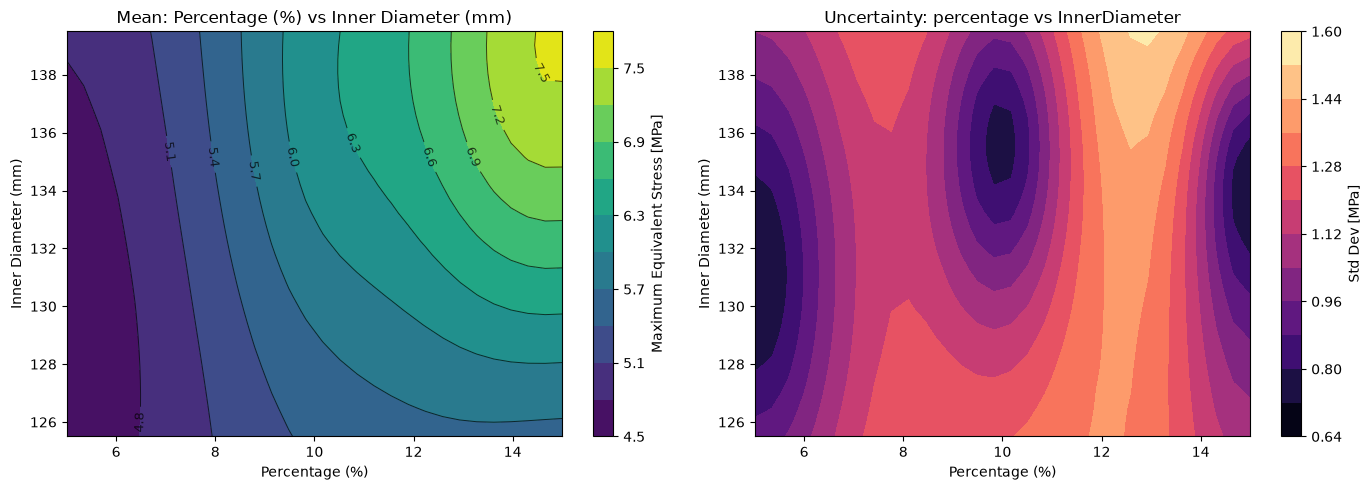

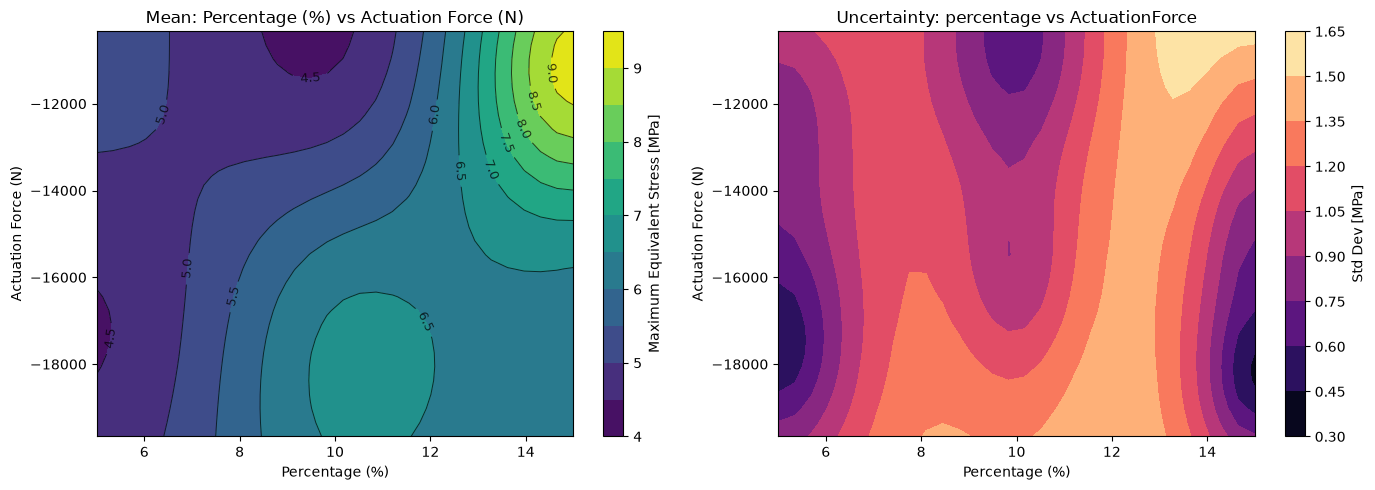

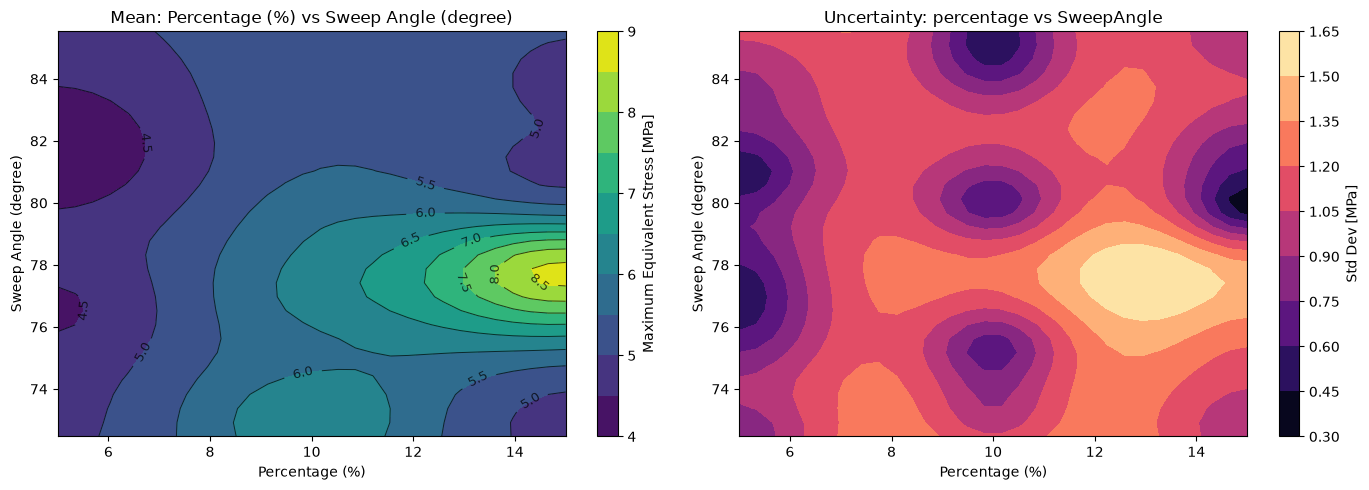

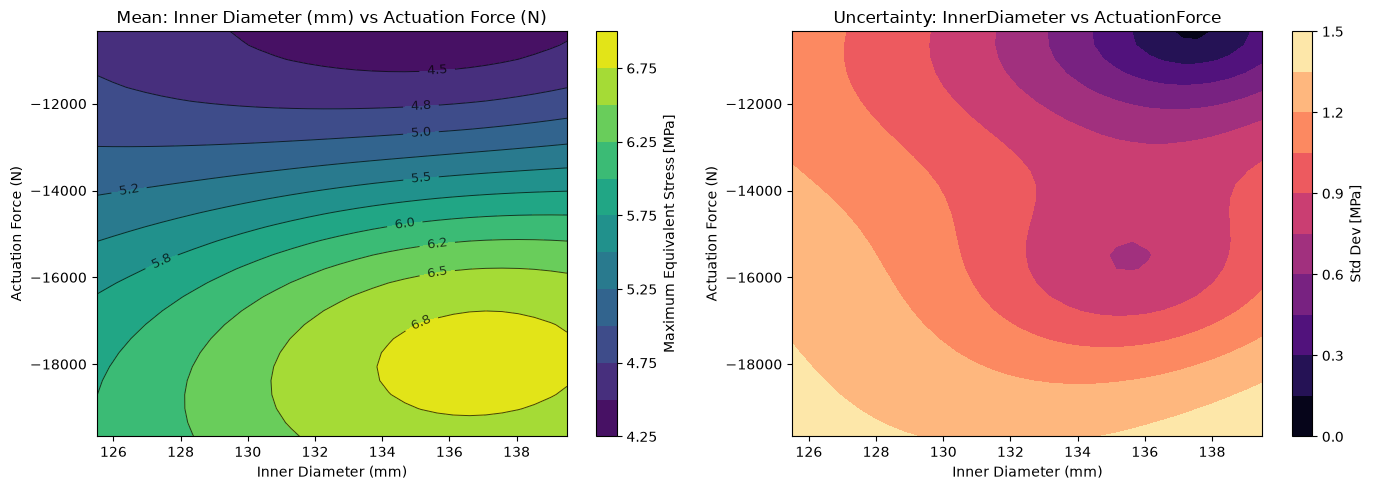

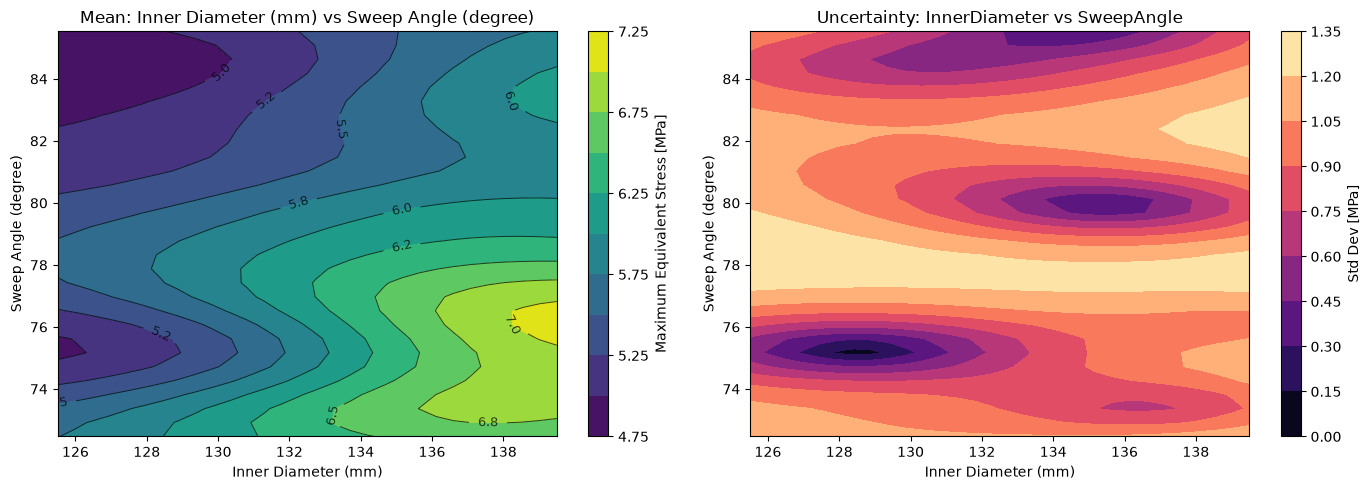

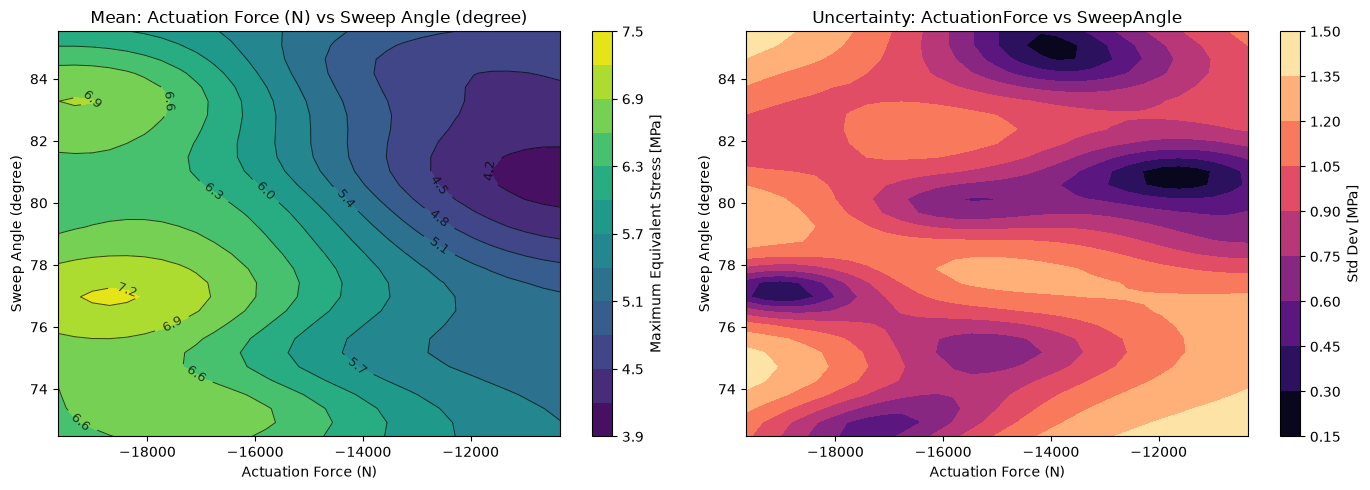

In [8]:
import itertools

features = ['percentage', 'InnerDiameter', 'ActuationForce', 'SweepAngle']
features_disp = ['Percentage (%)', 'Inner Diameter (mm)', 'Actuation Force (N)', 'Sweep Angle (degree)']
combinations = list(itertools.combinations(features, 2))
n_points = 30 # Reduced for plotting speed

#Mapping Name for Better Visualization

name_map=dict(zip(features,features_disp))

for feat1, feat2 in combinations:
    x1_range = np.linspace(X[feat1].min(), X[feat1].max(), n_points)
    x2_range = np.linspace(X[feat2].min(), X[feat2].max(), n_points)
    X1, X2 = np.meshgrid(x1_range, x2_range)

    # Prepare grid input with mean values for unspecified features
    grid_data = pd.DataFrame([X_train.mean()] * (n_points**2), columns=features)
    grid_data[feat1] = X1.ravel()
    grid_data[feat2] = X2.ravel()

    grid_scaled = scaler_X.transform(grid_data)
    y_mu_log, y_std_log = best_gpr.predict(grid_scaled, return_std=True)
    y_mu = np.expm1(y_mu_log)
    y_std = np.exp(y_mu_log) * y_std_log

    Z_mu = y_mu.reshape(n_points, n_points)
    Z_std = y_std.reshape(n_points, n_points)

    disp_feat1=name_map[feat1]
    disp_feat2=name_map[feat2]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Mean
    c1 = ax1.contourf(X1, X2, Z_mu, levels=10, cmap='viridis')
    fig.colorbar(c1, ax=ax1, label='Maximum Equivalent Stress [MPa]')

    lines = ax1.contour(X1, X2, Z_mu, levels=10, colors='black', linewidths=0.7, alpha=0.7)
    ax1.clabel(lines, inline=True, fontsize=9, fmt='%.1f')

    ax1.set_title(f'Mean: {disp_feat1} vs {disp_feat2}')
    ax1.set_xlabel(disp_feat1)
    ax1.set_ylabel(disp_feat2)

    # Plot Std Dev
    c2 = ax2.contourf(X1, X2, Z_std, levels=10, cmap='magma')
    fig.colorbar(c2, ax=ax2, label='Std Dev [MPa]')
    ax2.set_title(f'Uncertainty: {feat1} vs {feat2}')
    ax2.set_xlabel(disp_feat1)
    ax2.set_ylabel(disp_feat2)

    plt.tight_layout()
    plt.show()

### 6. Sensitivity Analysis: 1D Marginal Effects
To isolate the impact of individual design choices, we plot the predicted Maximum Equivalent Stress against each variable while holding all others at their mean value. The shaded **95% Confidence Interval** illustrates the model's localized reliability.

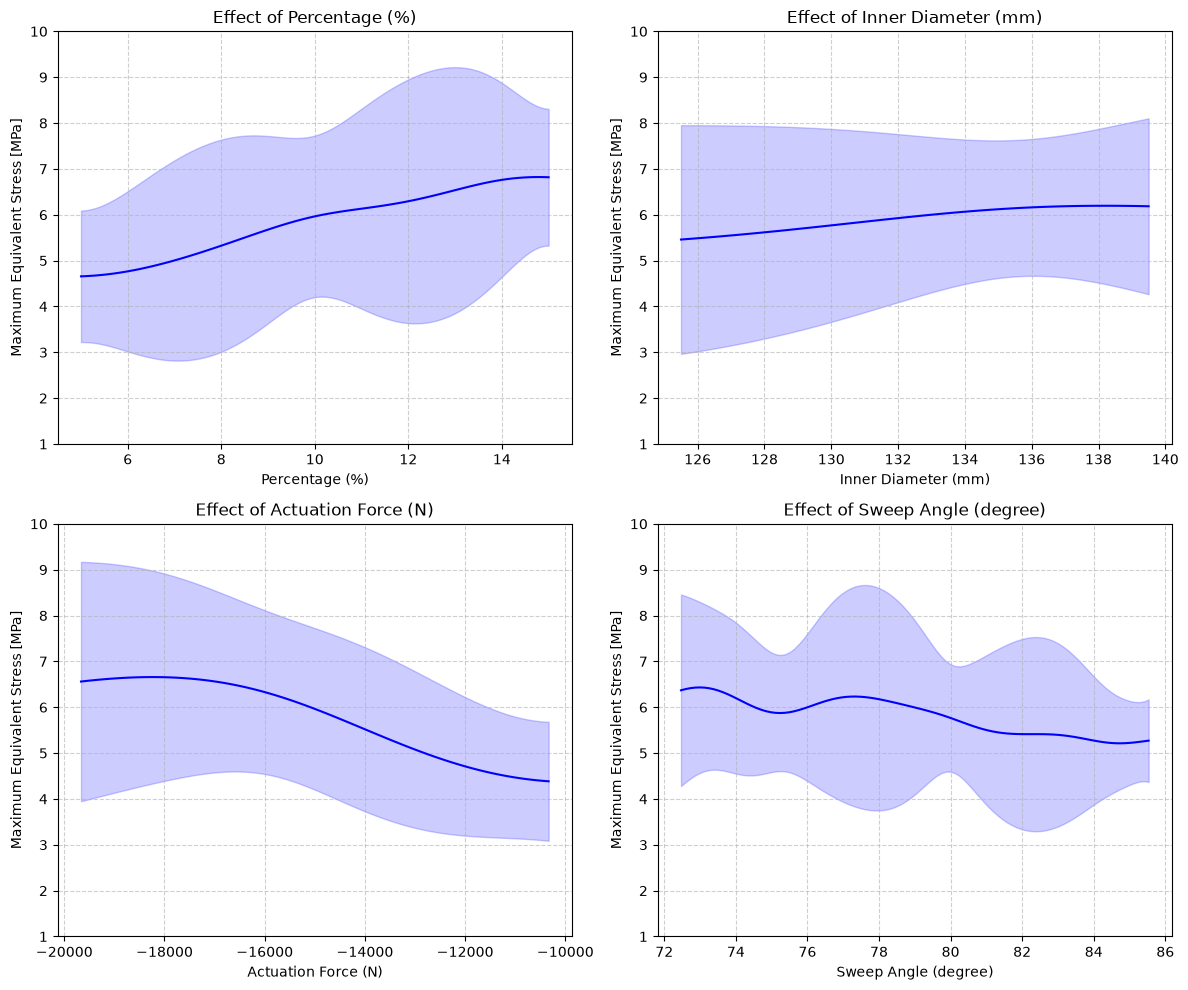

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    x_line = np.linspace(X[feature].min(), X[feature].max(), 100)
    line_data = pd.DataFrame([X_train.mean()] * 100, columns=features)
    line_data[feature] = x_line

    line_scaled = scaler_X.transform(line_data)
    y_mu_log, y_std_log = best_gpr.predict(line_scaled, return_std=True)
    y_mu = np.expm1(y_mu_log)
    y_std = np.exp(y_mu_log) * y_std_log

    disp_feature=name_map[feature]

    axes[i].set_ylim([1, 10])  
    axes[i].plot(x_line, y_mu, color='blue', label='Mean Prediction')
    axes[i].fill_between(x_line, y_mu - 1.96*y_std, y_mu + 1.96*y_std, color='blue', alpha=0.2, label='95% CI')
    axes[i].set_title(f'Effect of {disp_feature}')
    axes[i].set_xlabel(disp_feature)
    axes[i].set_ylabel('Maximum Equivalent Stress [MPa]')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 7. Noise Sensitivity Analysis
We compare the optimized model (with small alpha) against a purely interpolating model (alpha=0) to see if the noise term improves numerical stability or overly smooths the FEA results.

In [10]:
from sklearn.metrics import mean_squared_error

# Model 1: Zero additional alpha while retaining the fitted white-noise kernel.
gpr_zero_alpha = GaussianProcessRegressor(kernel=best_gpr.kernel_, alpha=0, normalize_y=True, random_state=42)
gpr_zero_alpha.fit(X_train_scaled, y_train_log)

# Model 2: Current optimized model with tuned alpha and white noise.
zero_alpha_train = np.expm1(gpr_zero_alpha.predict(X_train_scaled))
optimized_train = np.expm1(best_gpr.predict(X_train_scaled))

print(f"Zero-alpha Model Test R2: {stress_r2(gpr_zero_alpha, X_test_scaled, y_test):.6f}")
print(f"Optimized Model (alpha={best_gpr.alpha}) Test R2: {stress_r2(best_gpr, X_test_scaled, y_test):.6f}")
print(f"Zero-alpha Train MSE: {mean_squared_error(y_train, zero_alpha_train):.2e}")
print(f"Optimized Train MSE: {mean_squared_error(y_train, optimized_train):.2e}")

Zero-alpha Model Test R2: 0.389854
Optimized Model (alpha=1e-10) Test R2: 0.389834
Zero-alpha Train MSE: 7.38e-12
Optimized Train MSE: 7.38e-12


### 8. Design Optimization

We use **Differential Evolution** to identify the design configuration that minimizes the predicted Maximum Equivalent Stress. The optimization bounds are defined using the minimum and maximum observed values for each design feature.

Because `differential_evolution` minimizes an objective function, the predicted stress is returned directly as the objective.

The minimum-stress design variables and corresponding predicted stress are then displayed.

In [11]:
from scipy.optimize import differential_evolution

features = ['percentage', 'InnerDiameter', 'ActuationForce', 'SweepAngle']
feature_units = {
    'percentage': '%',
    'InnerDiameter': 'mm',
    'ActuationForce': 'N',
    'SweepAngle': 'degree',
}

# Search the continuous design space bounded by the observed data.
bounds = [(X[feature].min(), X[feature].max()) for feature in features]


def objective(values):
    candidate = pd.DataFrame([values], columns=features)
    candidate_scaled = scaler_X.transform(candidate)
    predicted_stress = np.expm1(best_gpr.predict(candidate_scaled)[0])
    return predicted_stress


optimization = differential_evolution(
    objective,
    bounds=bounds,
    seed=42,
    polish=True,
)

# Predict the stress and uncertainty at the minimum-stress candidate.
optimal_candidate = pd.DataFrame([optimization.x], columns=features)
optimal_candidate_scaled = scaler_X.transform(optimal_candidate)
stress_mean_log, stress_std_log = best_gpr.predict(
    optimal_candidate_scaled,
    return_std=True,
)

optimal_stress = float(np.expm1(stress_mean_log[0]))
uncertainty = float(np.exp(stress_mean_log[0]) * stress_std_log[0])
stress_lower = optimal_stress - 1.96 * uncertainty
stress_upper = optimal_stress + 1.96 * uncertainty
continuous_optimum = dict(zip(features, optimization.x))

# Present the recommended design in a compact, unit-aware table.
optimal_design = pd.DataFrame({
    'Parameter': features,
    'Unit': [feature_units[feature] for feature in features],
    'Lower Bound': [bound[0] for bound in bounds],
    'Optimal Value': [continuous_optimum[feature] for feature in features],
    'Upper Bound': [bound[1] for bound in bounds],
})

# Present model performance separately from the design variables.
optimization_summary = pd.DataFrame({
    'Metric': [
        'Predicted minimum equivalent stress',
        'Prediction standard deviation',
        'Approximate 95% lower limit',
        'Approximate 95% upper limit',
        'Optimization successful',
    ],
    'Value': [
        f'{optimal_stress:.3f}',
        f'{uncertainty:.3f}',
        f'{stress_lower:.3f}',
        f'{stress_upper:.3f}',
        'Yes' if optimization.success else 'No',
    ],
    'Unit': ['MPa', 'MPa', 'MPa', 'MPa', ''],
})

print('Minimum-stress design')
display(optimal_design.round(3).reset_index(drop=True))

print('Optimization result')
display(optimization_summary)

Minimum-stress design


,Parameter,Unit,Lower Bound,Optimal Value,Upper Bound
0,percentage,%,5.000,14.909,15.000
1,InnerDiameter,mm,125.500,131.080,139.500
2,ActuationForce,N,-19666.667,-10341.557,-10333.333
3,SweepAngle,degree,72.467,82.744,85.533


Optimization result


,Metric,Value,Unit
0,Predicted minimum equivalent stress,3.561,MPa
1,Prediction standard deviation,0.318,MPa
2,Approximate 95% lower limit,2.937,MPa
3,Approximate 95% upper limit,4.184,MPa
4,Optimization successful,Yes,
